<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

**ESPECIALIZACIÓN EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL**

*INTRODUCCION A LA CIENCIA DE DATOS*<br>

DOCENTE:<br>
Mateo Cano Solis<br>

NOMBRES:
1. Santiago Castañeda Garcia
2. Andres Eduardo Medina
3. David Alejandro Montilla Orjuela



Abril 2026


---

# **Análisis Predictivo y Caracterización de la Contratación Estatal en Colombia: Un Enfoque Basado en Datos de SECOP I y II**

## **1. introducción:**
La contratación pública en Colombia representa uno de los pilares más importantes para el desarrollo socioeconómico del país. Con la transición y coexistencia de las plataformas SECOP I y SECOP II, se ha generado un volumen de información sin precedentes sobre cómo el Estado invierte sus recursos. Sin embargo, la complejidad y diversidad de estos datos exigen el uso de herramientas avanzadas de Analítica de Datos para transformar registros administrativos en conocimiento estratégico.

Este proyecto se enfoca en el estudio de los procesos de compra pública que han culminado en contratos efectivos. A través de técnicas de Aprendizaje Automático (Machine Learning), se busca descubrir patrones ocultos en las modalidades de selección, los tiempos de ejecución y la distribución de los presupuestos, permitiendo una visión técnica que aporte a la transparencia y a la eficiencia en la gestión pública

<br><br>

## **2. Objetivos:**

Objetivo General
Desarrollar un modelo de análisis basado en técnicas de aprendizaje automático para caracterizar y predecir métricas clave en los procesos de contratación estatal integrados en las plataformas SECOP I y II.

Objetivos Específicos
Realizar un Análisis Exploratorio de Datos (EDA) para identificar las tendencias de contratación por sectores, regiones y modalidades de selección.

Procesar y estandarizar la información integrada de SECOP I y II, gestionando la limpieza de datos faltantes y la codificación de variables categóricas.

Evaluar diferentes arquitecturas de modelos predictivos mediante el uso de herramientas de AutoML (como AutoGluon), con el fin de determinar el algoritmo que ofrezca mayor precisión en la clasificación o estimación de resultados contractuales.

Interpretar los resultados obtenidos para identificar qué variables (como cuantía, ubicación o tipo de entidad) tienen mayor peso en la configuración de un contrato exitoso.

<br>
VARIABLES OBSERVADAS
<br><br>

|Num|Nombre de la columna|Descripción|Nombre del campo API|Tipo de dato|
|-|-|-|-|-|
|1|Nivel Entidad|Nivel de la entidad publica que desarrolla el proceso de compra, de acuerdo a su cobertura|Nivel entidad|Texto|
|2|Código Entidad SECOP|Código de la entidad en la plataforma SEECOP|Código_entidad_en_secop|Texto |
|3|Nombre de la Entidad|Nombre de la Entidad que desarrolla el proceso de compra pública|nombre_de_la_entidad|Texto |
|4|NIT de la Entidad|	Identificador de la Entidad que desarrolla el proceso de compra pública|nit_de_la_entidad|	Texto|
|5|Departamento Entidad|	Departamento de origen de la Entidad en la plataforma SECOP|	departamento_entidad|	Texto|
|6|Municipio Entidad|	Municipio de origen de la Entidad en la plataforma SECOP|	municipio_entidad|	Texto|
|7|Estado del Proces|	Estado del proceso, de acuerdo con el flujo que se establece y a la modalidad de adquisición bajo la cual se desarrolla|	estado_del_proceso|	Texto|
|8|Modalidad de Contratación|	Modo de adquisición, de acuerdo con las características del proceso y del producto o servicio involucrados|	modalidad_de_contrataci_n|	Texto|
|9|Objeto del contrato|	Descripción detallada del producto o servicio a adquirir, definida al momento de redactar el contrato|	objeto_a_contratar|	Texto|
|10|Objeto del proceso|	Objeto de contratación registrado en la fase de publicación del proceso|	objeto_del_proceso|	Texto|
|11|Tipo de Contrato|	Tipo de contrato que se firma al finalizar el proceso de compra pública|	tipo_de_contrato|	Texto|
|12|Fecha de Firma del Contrato|	Fecha en que se firmó el contrato, sea de forma física o digital|	fecha_de_firma_del_contrato|	Marca de tiempo variable|
|13|Fecha inicio ejecución|	Fecha de Inicio de Ejecución del Contrato|	fecha_inicio_ejecuci_n|	Marca de tiempo variable|
|14|Fecha fin ejecución|	Fecha definida en el contrato como la fecha de finalización de la ejecución|	fecha_fin_ejecuci_n|	Marca de tiempo variable|
|15|ID Contrato|	Identificador en la plataforma del contrato firmado|	numero_del_contrato|	Texto|
|16|ID Proceso|	identificador en la plataforma del proceso desarrollado|	numero_de_proceso|	Texto|
|17|Valor Contrato|	Valor del contrato firmado|	valor_contrato	|numerica|
|18|Núm Raz Social Contratista|Nombre del contratista o de la empresa que proveerá los productos o servicios relacionados en el proceso de compra|num_raz_social_contratista|Texto|
|19|	URL Contrato|	URL del proceso en su correspondiente plataforma.|	url_contrato|	Texto|
|20	|Origen	|Plataforma Origen a donde pertenecen los datos|	origen	|Texto|
|21	|Tipo Documento Proveedor	|Corresponde al tipo de documento del proveedor	|tipo_documento_proveedor|	Texto|
|22|	Documento Proveedor	|Corresponde al número de documento del proveedor|	documento_proveedor	|Texto|






## **Carga de librerias y datos:**

In [76]:
#Importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report
import seaborn as sns
from autogluon.tabular import TabularPredictor
from tqdm import tqdm
import unicodedata
import re
from catboost import CatBoostRegressor

df = pd.read_parquet('data/datos_secop.parquet')

#visualizar todo el df en pantalla
pd.set_option('display.max_columns', None)

# generar variable para conteo final de Nas
filas_iniciales = len(df)

#numero de columnas y filas
print(f"El dataset tiene: {df.shape[0]} filas y {df.shape[1]} columnas")



El dataset tiene: 300000 filas y 22 columnas


## **Variables**

In [77]:
df.columns.tolist()

['nivel_entidad',
 'codigo_entidad_en_secop',
 'nombre_de_la_entidad',
 'nit_de_la_entidad',
 'departamento_entidad',
 'municipio_entidad',
 'estado_del_proceso',
 'modalidad_de_contrataci_n',
 'objeto_a_contratar',
 'objeto_del_proceso',
 'tipo_de_contrato',
 'fecha_de_firma_del_contrato',
 'fecha_inicio_ejecuci_n',
 'fecha_fin_ejecuci_n',
 'numero_del_contrato',
 'numero_de_proceso',
 'valor_contrato',
 'nom_raz_social_contratista',
 'url_contrato',
 'origen',
 'tipo_documento_proveedor',
 'documento_proveedor']

## **Visualizar el df**

In [78]:
# Mostrar  5 filas aleatorias
df.sample(5,random_state=25)



,nivel_entidad,codigo_entidad_en_secop,nombre_de_la_entidad,nit_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contrataci_n,objeto_a_contratar,objeto_del_proceso,tipo_de_contrato,fecha_de_firma_del_contrato,fecha_inicio_ejecuci_n,fecha_fin_ejecuci_n,numero_del_contrato,numero_de_proceso,valor_contrato,nom_raz_social_contratista,url_contrato,origen,tipo_documento_proveedor,documento_proveedor
98576,Territorial,706294725,MUNICIPIO DE PUERTO GAITAN,800079035,Meta,Puerto Gaitán,En ejecución,Contratación directa,PRESTACION DE SERVICIOS DE APOYO A LA GESTION ...,PRESTACION DE SERVICIOS DE APOYO A LA GESTION ...,Prestación de servicios,2025-10-24T00:00:00.000,2025-10-24T00:00:00.000,2025-12-24T00:00:00.000,CO1.PCCNTR.8496546,1457-2025,5693333,DANIELA STEFFANY ROJAS ORTIZ,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1124818345
267521,Territorial,702730482,SUBRED INTEGRADA DE SERVICIOS DE SALUD SUR E.S...,900958564,Distrito Capital de Bogotá,Bogotá,Modificado,Contratación régimen especial,PRESTAR SERVICIOS COMO PROFESIONAL UNIVERSITAR...,PRESTAR SERVICIOS COMO PROFESIONAL UNIVERSITAR...,Prestación de servicios,2025-10-02T00:00:00.000,2025-10-02T00:00:00.000,2026-01-09T00:00:00.000,CO1.PCCNTR.8401984,7218-2025,12585600,Milena Stefany Lopez Ramirez,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1018450196
286023,Territorial,701365033,MUNICIPIO DE ARMENIA QUINDIO,890000464,Quindío,Armenia,Aprobado,Contratación directa,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Prestación de servicios,2025-11-27T00:00:00.000,None,2026-01-15T00:00:00.000,CO1.PCCNTR.8635700,SETTA-CD-2025-4677,3750000,Oscar Posada Yepes,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,7529900
11020,Territorial,702727421,empresa social del estado región de salud soacha.,8000068503,Cundinamarca,Soacha,Borrador,Contratación régimen especial,NO DEFINIDO,Sin Descripcion,Prestación de servicios,None,None,None,CO1.PCCNTR.272027,CO1.PCCNTR.272027,0,NO DEFINIDO,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Sin Descripcion,No Definido
219736,Territorial,702271321,(Secretaría Distrital de Integración Social),8999990619,Distrito Capital de Bogotá,No Definido,Aprobado,Contratación directa,PRESTAR SERVICIOS PROFESIONALES PARA REALIZAR ...,PRESTAR SERVICIOS PROFESIONALES PARA REALIZAR ...,Prestación de servicios,2025-11-18T00:00:00.000,None,2026-03-12T00:00:00.000,CO1.PCCNTR.8568972,11671-2025,15137640,DASSY MILENA GUTIERREZ,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,52288055


## **EDA**

In [79]:
# Obtener un resumen de la estructura del conjunto de datos:

print("\n-------TABLA CON TIPO DE VARIABLE VALORES UNICOS Y VALORES FALTANTES-------\n")
def generar_diccionario(Data):
    dicc = []
    for col in Data.columns:
        dicc.append({
            "Variable": col,
            "Tipo pandas": Data[col].dtype,
            "Cantidad de valores únicos": Data[col].nunique(),
            "Valores faltantes": Data[col].isna().sum()
        })
    return pd.DataFrame(dicc)

generar_diccionario(df)


-------TABLA CON TIPO DE VARIABLE VALORES UNICOS Y VALORES FALTANTES-------



,Variable,Tipo pandas,Cantidad de valores únicos,Valores faltantes
0,nivel_entidad,object,7,0
1,codigo_entidad_en_secop,object,5103,0
2,nombre_de_la_entidad,object,5239,0
3,nit_de_la_entidad,object,4200,0
4,departamento_entidad,object,38,0
5,municipio_entidad,object,1079,0
6,estado_del_proceso,object,19,0
7,modalidad_de_contrataci_n,object,31,0
8,objeto_a_contratar,object,165211,0
9,objeto_del_proceso,object,172952,1


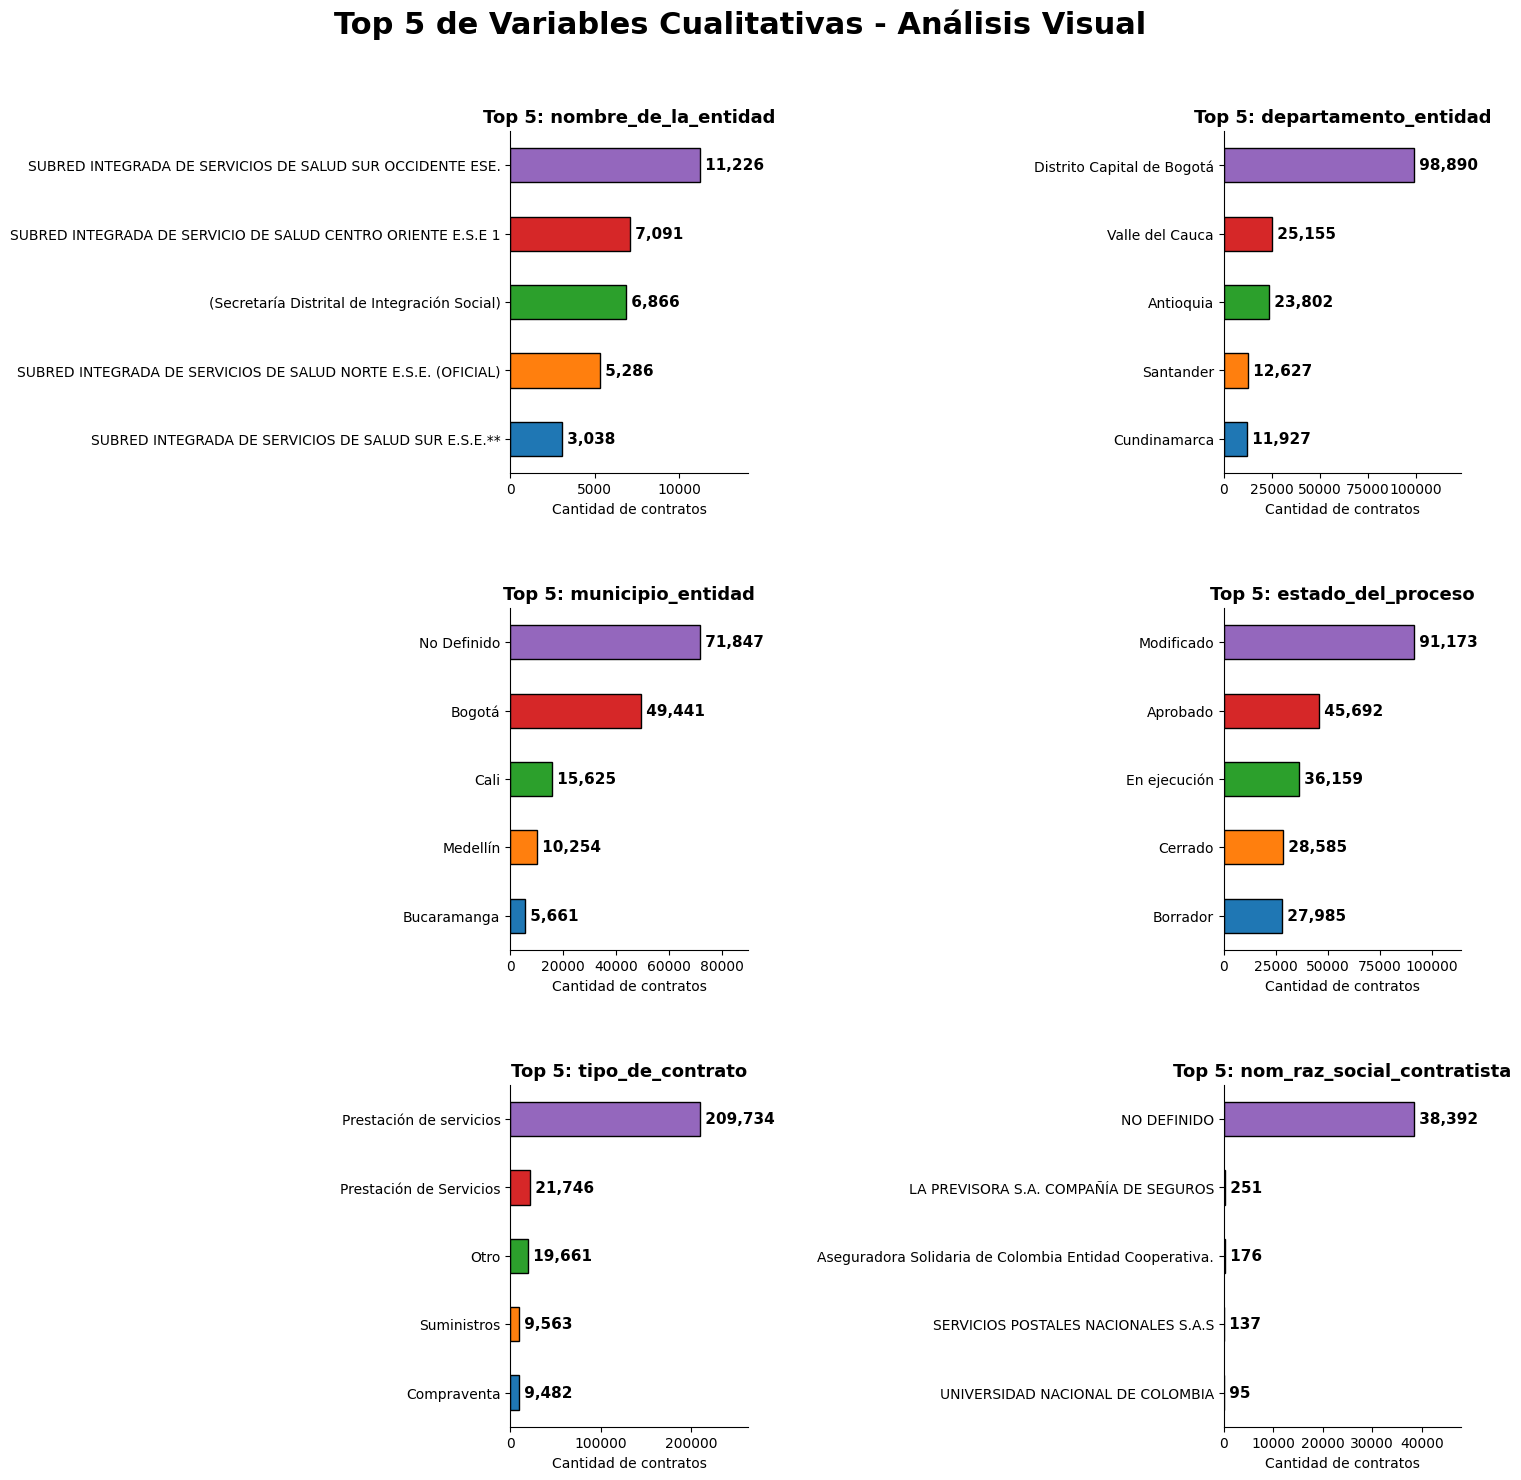

In [80]:
# 1. Configuración de variables y grid
vars_cualitativas = [
    'nombre_de_la_entidad', 'departamento_entidad', 'municipio_entidad', 
    'estado_del_proceso', 'tipo_de_contrato', 'nom_raz_social_contratista'
]

cols_grid = 2
rows_grid = math.ceil(len(vars_cualitativas) / cols_grid)

# Paleta de colores
colores_paleta = plt.cm.tab10.colors 

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(16, rows_grid * 5))
axes = axes.flatten()

for i, col in enumerate(vars_cualitativas):
    if col in df.columns:
        # Top 5 ordenado
        datos = df[col].value_counts().head(5).sort_values(ascending=True)

        ax = axes[i]
        
        # --- CAMBIO: Eliminamos 'label' para que no haya leyenda ---
        datos.plot(
            kind='barh', 
            ax=ax, 
            color=colores_paleta[:len(datos)], 
            edgecolor='black'
        )

        ax.set_title(f'Top 5: {col}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Cantidad de contratos')
        ax.set_ylabel('')

        # --- CAMBIO: Eliminamos ax.legend() ---
        # La leyenda ya no se mostrará.

        # Estética
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Etiquetas de datos al final de la barra (aquí ya está el número)
        max_valor = datos.max()
        for p in ax.patches:
            ancho = p.get_width()
            ax.annotate(
                f' {int(ancho):,}', 
                (ancho, p.get_y() + p.get_height()/2.),
                va='center', 
                ha='left', 
                fontsize=11, 
                fontweight='bold'
            )
        
        ax.set_xlim(0, max_valor * 1.25)

    else:
        axes[i].axis('off')

# Ajustes finales
plt.tight_layout(pad=5.0)
fig.suptitle(
    'Top 5 de Variables Cualitativas - Análisis Visual',
    fontsize=22,
    fontweight='bold',
    y=1.02
)

plt.show()

## **Renombrar columnas**

In [81]:
# Quitar guion para los nombres de las columnas
df.rename(columns={'modalidad_de_contrataci_n': 'modalidad_de_contratacion', 'fecha_inicio_ejecuci_n': 'fecha_inicio_ejecucion',
    'fecha_fin_ejecuci_n': 'fecha_fin_ejecucion'},
    inplace=True)

In [82]:
# quitar tildes pasar a minusculas y eliminar caracteres especiales y quitar guiones en las filas del df

def limpieza_total(texto):
    if pd.isna(texto):
        return ""
    
    # 1. Convertir a minúsculas
    texto = str(texto).lower()
    
    # 2. Quitar tildes (Normalizar)
    texto = unicodedata.normalize('NFKD', texto)\
            .encode('ascii', 'ignore')\
            .decode('utf-8')
    
    # 3. Quitar guiones (-), tabulaciones (\t) y saltos de línea (\n)
    # Los reemplazamos por un espacio para evitar que las palabras se peguen
    texto = re.sub(r'[-\t\n\r]', ' ', texto)
    
    # 4. Quitar caracteres especiales 
    # Esto deja solo letras y espacios, quitando puntos, comas, etc.
    texto = re.sub(r'[^a-z\s]', '', texto) 
    
    # 5. Limpiar espacios extra
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    return texto

# 1. Definimos la lista de columnas que queremos limpiar
columnas_a_limpiar = [
    'nivel_entidad', 'nombre_de_la_entidad', 'departamento_entidad',
    'municipio_entidad', 'estado_del_proceso', 'modalidad_de_contratacion',
    'objeto_del_proceso' ]

# 2. Aplicamos la función a cada una de esas columnas
for col in columnas_a_limpiar:
    # Usamos .apply para limpiar cada celda de la columna actual
    df[col] = df[col].apply(limpieza_total)



## **Data cleaning**

OBSERVACION: Existe en la columna (estado_del_proceso) contratos que estan en  borrador. lo que significa  que aun no están publicados oficialmente o no ha sido adjudicado o está en proceso de elaboración o revisión, por lo que carece de mucha de informacion en otras columnas, estas filas se eliminan para tener solo los contratos que ya pasaron la etapa de creación inicial

In [83]:
#Borrar contratos en estado borrador

df = df[df['estado_del_proceso'] != 'borrador'].copy()

#comprobamos cuantas filas quedan
print(f"el numero de filas resultantes es {df.shape[0]}")

#numero de filas sin fecha de inicio de ejcucion
filas_sin_fecha_ejecucion=df['fecha_inicio_ejecucion'].isna().sum()
print(f"el numero de filas sin fecha de inicio de ejcucion es: {filas_sin_fecha_ejecucion}")

el numero de filas resultantes es 272015
el numero de filas sin fecha de inicio de ejcucion es: 75269


OBSERVACION: El dataset nos quedo con 272015 filas lo cual nos dice que exisitian  27958 contratos que a la fecha no se han aprobado y fueron eliminados para nuestro estudio, ademas tenemos  75269  filas que no tienen fecha de inicio de ejecucion (fecha_inicio_ejecucion), esto puede deberse que el contrato aun no se ha iniciado por lo que no debe tener fecha de terminacion (fecha_fin_ejecucion). Buscamos las filas que no tienen fechas en ninguna de las dos columnas (fantasmas).

Pasar variables de fecha a formato datetime


In [84]:
cols = ['fecha_de_firma_del_contrato', 'fecha_inicio_ejecucion', 'fecha_fin_ejecucion']

df[cols] = df[cols].apply(
    lambda x: pd.to_datetime(x, errors='coerce').dt.normalize()
)

In [85]:
# 1. Obtenemos los índices de las filas con fecha de inicio nula
indices_sin_inicio = set(df[df['fecha_inicio_ejecucion'].isna()].index)

# 2. Obtenemos los índices de las filas con fecha de fin nula
indices_sin_fin = set(df[df['fecha_fin_ejecucion'].isna()].index)

# 3. Usamos la intersección (&) para saber cuáles no tienen NINGUNA de las dos
filas_sin_ambas = indices_sin_inicio & indices_sin_fin

print(f"Cantidad de contratos sin ambas fechas: {len(filas_sin_ambas)}")

df_fantasmas = df.loc[list(filas_sin_ambas)]



Cantidad de contratos sin ambas fechas: 26839


Existen 26839 contratos sin fechas de inicio y de ejecucion, y comprobamos los estados del proceso para las filas que no tienen fechas de inicio de ejecucion ni fin de ejecucion.

In [86]:
df_fantasmas["estado_del_proceso"].unique()

array(['convocado', 'adjudicado',
       'terminado anormalmente despues de convocado', 'descartado',
       'cancelado', 'publicacion para manifestaciones de interes',
       'enviado proveedor', 'aprobado'], dtype=object)

OBERVACION:

estos estados corroboran la siguiente informacion


El grupo de "No llegaron a nacer" (Convocado, Adjudicado, Aprobado)
Convocado / Publicación para manifestaciones: El proceso apenas está en licitación. La entidad está buscando quién lo haga. No hay fechas de ejecución porque no hay contrato todavía.

Adjudicado: Ya hay un ganador, pero están en el trámite de firmas. El reloj de la ejecución no ha empezado a correr.

Aprobado / Enviado Proveedor: Son estados de la plataforma SECOP II donde el documento está en "bandeja de entrada", pero no se ha formalizado el acta de inicio.

El grupo de "Muerte Súbita" (Cancelado, Descartado, Terminado Anormalmente)
Cancelado / Descartado: La entidad decidió no seguir adelante antes de que empezara el trabajo. Es lógico que no tengan fechas de inicio ni fin, porque el contrato murió en el papel.

Terminado Anormalmente después de Convocado: Este es muy interesante para las anomalías. Significa que el proceso se rompió justo después de abrirse. Puede ser por falta de oferentes, errores en los pliegos o incluso denuncias de corrupción que frenaron el proceso.


Para nuestro estudio eliminaremos estas filas ya que necesitaremos fechas para poder correr nuestro modelo

In [87]:
#Elimina filas sin ambas fechas

df = df.drop(index=list(filas_sin_ambas)).copy()



## **Imputacion**

aun tenemos 48430 filas sin (fecha_inicio_ejecucion) por lo que hacemos imputacion de estos valores con la (fecha_de_firma_del_contrato) ya que muchos contratos inician el mismo día que se firman. 

In [88]:
print("-----Valores faltantes------")
df[cols].isna().sum()



-----Valores faltantes------


fecha_de_firma_del_contrato     6158
fecha_inicio_ejecucion         48430
fecha_fin_ejecucion               10
dtype: int64

In [89]:
# Imputar fehca de firma de contrato a fecha inicio de ejecucion
df['fecha_inicio_ejecucion'] = df['fecha_inicio_ejecucion'].fillna(df['fecha_de_firma_del_contrato'])

In [90]:
print("-----Valores faltantes------")
df[cols].isna().sum()

-----Valores faltantes------


fecha_de_firma_del_contrato    6158
fecha_inicio_ejecucion         2821
fecha_fin_ejecucion              10
dtype: int64

Borramos los que aún no tienen fecha de inicio (porque no tenían fecha de firma para rescatarlos)

In [91]:
# 1. Convertimos espacios vacíos o celdas con solo espacios en NaN reales para AMBAS columnas
columnas_fechas = ['fecha_inicio_ejecucion', 'fecha_fin_ejecucion']

for col in columnas_fechas:
    df[col] = df[col].replace(r'^\s*$', np.nan, regex=True)

# 2. Ahora aplicamos el dropna asegurándonos de guardar el resultado en la variable
df = df.dropna(subset=columnas_fechas).copy()




Aunque se eliminaron el 19.22 % de los datos, aun contamos con 242345 datos en nuestro dataset

## **Nueva variable duracion del contrato**

Creamos una variable que nos diga cuanto duro el contrato en dias

In [92]:
#Calculamos la duración en días
df['duracion_dias'] = (df['fecha_fin_ejecucion'] - df['fecha_inicio_ejecucion']).dt.days

#Revisamos si hay anomalías obvias de inmediato
print("Estadísticas de la duración:")
print(df['duracion_dias'].describe())

#(Duración negativa)
negativos = (df['duracion_dias'] < 0).sum()
print(f"\n Contratos con fechas invertidas: {negativos}")


# Verificación final
print(df[columnas_fechas].isnull().sum())


Estadísticas de la duración:
count    242345.000000
mean        159.829780
std         222.480315
min       -7256.000000
25%          49.000000
50%         105.000000
75%         251.000000
max       11688.000000
Name: duracion_dias, dtype: float64

 Contratos con fechas invertidas: 886
fecha_inicio_ejecucion    0
fecha_fin_ejecucion       0
dtype: int64


existen 886 contratos con duraciones negativas esto puede deberse a errores de digitacion, para nuestro ejercicio eliminamos esas filas, estos serian contratos a revisar, pero para nuestro estudio estos contratos no aportarian informacion, por lo que los eliminamos del dataset.

In [93]:
# 1. Filtramos para trabajar solo con duraciones lógicas (mayores a 0)
df = df[df['duracion_dias'] > 0].copy()



In [94]:
filas_finales=len(df)

porcentaje_filas_eliminadas = (filas_iniciales - filas_finales)*100/filas_iniciales

print(f"\n filas con fechas completas: {filas_finales}")
print(f"\n filas iniciales dataset: {filas_iniciales}")
print(f"\n porcentaje eliminados: {round(porcentaje_filas_eliminadas,2)} %")


 filas con fechas completas: 240909

 filas iniciales dataset: 300000

 porcentaje eliminados: 19.7 %


Creamos una nueva variable llamada anio para extraer el año de la fecha de ejecucion del contrato


In [95]:


df['anio'] = df['fecha_inicio_ejecucion'].dt.year.astype('Int64')



ponemos como indice del df el numero del contrato

In [96]:
ids = df['numero_del_contrato']

Para nuestro modelado tomas una muestra de 20000 filas para poder hacer las corridas mas rapido, este muestreo se hace aleatoriamente

In [97]:
df_modelado = df.sample(n=20000, random_state=42).copy()

eliminamos filas que no necesitamos en los modelos

In [98]:
columns_eliminar = ["codigo_entidad_en_secop", 
                    "nombre_de_la_entidad",
                    "nit_de_la_entidad",  
                    "numero_de_proceso",
                    "objeto_a_contratar",
                    "nom_raz_social_contratista",
                    "documento_proveedor", 
                    "url_contrato",
                    "numero_del_contrato",
                    "fecha_de_firma_del_contrato",
                    "tipo_documento_proveedor",
                    "fecha_inicio_ejecucion",
                    "fecha_fin_ejecucion"]

df_modelado= df.drop(columns=columns_eliminar).copy()

En nuestro ejercicio, para poder hacer las corridas mas viables tomamos de nuestro df_modelado solo 20000 filas de forma aleatoria, con un muestreo esratificado ya que en el SECOP existen mas contratos pequeños que contratos grandes, siendo esta distribucion sesgada.


In [99]:
df_modelado['bins'] = pd.qcut(df_modelado['valor_contrato'], q=10, duplicates='drop')

df_sample = df_modelado.groupby('bins', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 2000), random_state=42)
)

df_sample = df_sample.drop(columns='bins').reset_index(drop=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_22008\3082278979.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sample = df_modelado.groupby('bins', group_keys=False).apply(
C:\Users\ACER\AppData\Local\Temp\ipykernel_22008\3082278979.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df_modelado.groupby('bins', group_keys=False).apply(


In [100]:
generar_diccionario(df_modelado)

,Variable,Tipo pandas,Cantidad de valores únicos,Valores faltantes
0,nivel_entidad,object,4,0
1,departamento_entidad,object,36,0
2,municipio_entidad,object,1000,0
3,estado_del_proceso,object,14,0
4,modalidad_de_contratacion,object,22,0
5,objeto_del_proceso,object,140507,0
6,tipo_de_contrato,object,31,0
7,valor_contrato,int64,89638,0
8,origen,object,2,0
9,duracion_dias,int64,1484,0


## **VARIABLE TARGET**

para nuestro modelo CatBost tendremos 3 datasets para analizar:
1) sin la columna objeto del proceso
2) con TF-IDF
3) con las categorias ya creadas

## *CatBost sin columna objeto del proceso*

In [101]:
df_mod_CatBost_1= df_modelado.loc[:, df_modelado.columns != "objeto_del_proceso"]

In [102]:
generar_diccionario(df_mod_CatBost_1)

,Variable,Tipo pandas,Cantidad de valores únicos,Valores faltantes
0,nivel_entidad,object,4,0
1,departamento_entidad,object,36,0
2,municipio_entidad,object,1000,0
3,estado_del_proceso,object,14,0
4,modalidad_de_contratacion,object,22,0
5,tipo_de_contrato,object,31,0
6,valor_contrato,int64,89638,0
7,origen,object,2,0
8,duracion_dias,int64,1484,0
9,anio,Int64,19,0


Ya que puede existir un sesgo en el valor de lso cantratos hacemos una transformacion logaritmica a nuestra valriable target

In [103]:
# target (con log)
y = np.log1p(df['valor_contrato'])  

X = df_mod_CatBost_1.drop(columns=['valor_contrato'])
cat_cols = X.select_dtypes(include=["object", "category"]).columns
num_cols = X.select_dtypes(exclude=["object", "category"]).columns

# categóricas
X[cat_cols] = X[cat_cols].astype(str).replace("nan", "missing")

# numéricas
X[num_cols] = X[num_cols].fillna(0)



## **Train /Test Split**

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,  random_state=42
)

Entrenar CatBoost

In [ ]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_cols
)

Evaluar

In [ ]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)

# volver a escala real
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print("RMSE:", rmse)

transformar la variable target ( valor_contrato)

In [ ]:
#y = np.log1p(y)

Ya con el df definitivo para nuestro modelo creamos un df alterno para hacer clusterin de la variable 'objeto_del_proceso' y obtener las categorias.

In [106]:
#df_col = df_modelo[['numero_del_contrato', 'objeto_del_proceso']]


#df_col.to_csv('data/objeto_contratos.csv', index=False, encoding='utf-8')



Una vez realizado el clustering y entreado a la IA el archivo para generar las categorias obtuvimos las siguientes 17 categorias:

In [ ]:
# Carga el archivo que se generó clustering

df_clusters = pd.read_csv('data/contratos_con_clusters.csv')

cluster_map = {
    0: "Comunicaciones Institucionales",
    1: "Educación Inicial",
    2: "Servicios Generales Básicos",
    3: "Servicios Logísticos",
    4: "Mantenimiento Técnico Especializado",
    5: "Apoyo Administrativo General",
    6: "Servicios Profesionales Generales",
    7: "Gestión Territorial e Interior",
    8: "Apoyo Financiero y Contable",
    9: "Servicios de Salud Asistencial",
    10: "Servicios Jurídicos Institucionales",
    11: "Servicios Profesionales Independientes",
    12: "Suministro de Papelería y Aseo",
    13: "Servicios Médicos Especializados",
    14: "Representación Jurídica",
    15: "Apoyo Administrativo TIC",
    16: "Servicios Ambientales y Forestales",
    17: "Transporte Institucional",
    18: "Apoyo Secretarial y Administrativo",
    19: "Apoyo Asistencial en Salud",
    20: "Deporte y Recreación",
    21: "Formación y Capacitación",
    22: "Gestión Inmobiliaria",
    23: "Servicios Profesionales Administrativos"
}
# Aplicamos el nombre al dataframe de clusters
df_clusters['categoria_nombre'] = df_clusters['cluster_id'].map(cluster_map)

# Ver id y categorias
print(df_clusters[['numero_del_contrato', 'categoria_nombre']].head(10))


  numero_del_contrato                     categoria_nombre
0       15-12-4416408                 Deporte y Recreación
1       15-12-4418304                 Deporte y Recreación
2       15-12-4418312                 Deporte y Recreación
3       15-12-4418338                 Deporte y Recreación
4       16-12-4954064       Servicios de Salud Asistencial
5       16-12-4795000       Servicios de Salud Asistencial
6        17-4-6125323   Apoyo Secretarial y Administrativo
7       14-12-2823091                 Deporte y Recreación
8       16-12-4832149  Servicios Jurídicos Institucionales
9       16-12-4745749                 Deporte y Recreación


In [108]:
# Unimos df_modelo con las columnas de categoría de df_clusters
df_modelo_final = pd.merge(
    df_modelo, 
    df_clusters[['numero_del_contrato', 'cluster_id', 'categoria_nombre']], 
    on='numero_del_contrato', 
    how='left'
)


In [109]:
# Cuenta los valores nulos en las columnas nuevas
print(df_modelo_final[['cluster_id', 'categoria_nombre']].isnull().sum())

cluster_id          0
categoria_nombre    0
dtype: int64


Todas las filas fueron categorizadas

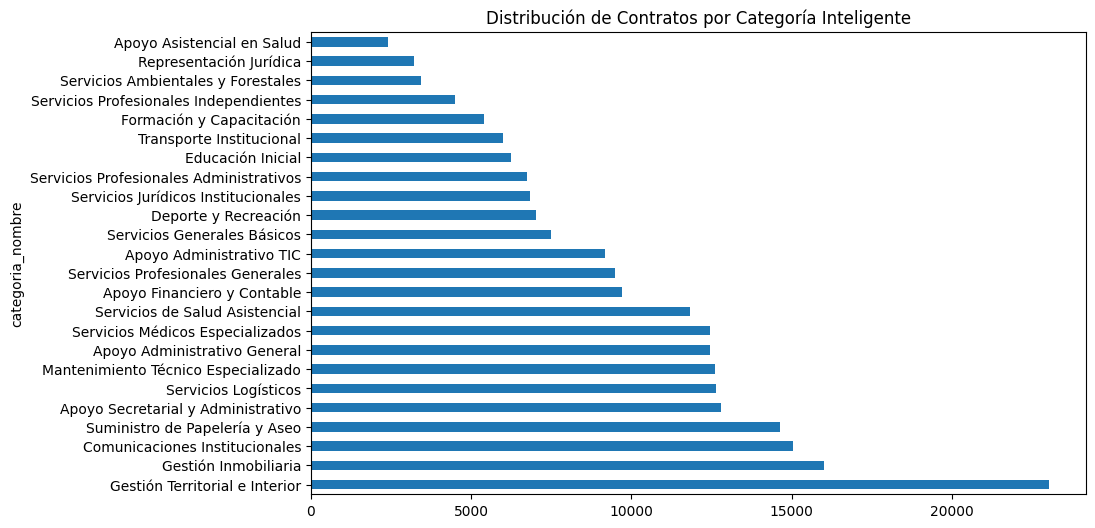

In [110]:
import matplotlib.pyplot as plt

# Contar cuántos contratos hay por categoría
df_modelo_final['categoria_nombre'].value_counts().plot(kind='barh', figsize=(10, 6))
plt.title('Distribución de Contratos por Categoría Inteligente')
plt.show()

In [111]:
from autogluon.tabular import TabularPredictor
import pandas as pd

# 1. Preparar el dataset
# Filtramos solo las columnas que vamos a usar para no saturar la RAM
features = [
    'valor_contrato', 'anio',  
    'municipio_entidad', 'estado_del_proceso', 
    'duracion_dias', 'categoria_nombre'
]

# Creamos una muestra para que el entrenamiento sea veloz (ej. 20,000 filas)
# Con 20k filas la tabla de modelos será estadísticamente confiable
df_sample = df_modelo_final[features].sample(n=1000, random_state=42)

# 2. Entrenar el Predictor
# label: tu variable objetivo
predictor = TabularPredictor(label='categoria_nombre', eval_metric='accuracy').fit(
    df_sample,
    presets='medium_quality', # 'medium' es ideal para 200k filas
    time_limit=600,           # Límite de 10 minutos
    num_stack_levels=0,       # Desactivamos el stacking para ganar velocidad
    excluded_model_types=['KNN', 'XT'] # Quitamos modelos lentos en datasets grandes
)

# 3. GENERAR LA TABLA (Leaderboard)
# La tabla se genera con la muestra para saber qué modelo es el mejor
tabla_modelos = predictor.leaderboard(df_sample, silent=True)

print("\n--- TABLA DE COMPARACIÓN (Muestra de 20k de 200k) ---")
print(tabla_modelos)

# 4. APLICAR AL DATASET COMPLETO (Para detectar los anormales)
# Una vez sabemos cuál es el mejor modelo, lo usamos para predecir en los 200k
print("\nCalculando predicciones para las 200,000 filas...")
predicciones = predictor.predict_proba(df_modelo_final[features])

# Ejemplo: Buscar anomalías (Contratos donde la probabilidad de la categoría real es baja)
# Esto te dirá cuáles de los 200k contratos no encajan con su descripción

No path specified. Models will be saved in: "AutogluonModels\ag-20260426_054057"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          12
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       2.39 GB / 15.71 GB (15.2%)
Disk Space Avail:   304.93 GB / 475.94 GB (64.1%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "c:\Users\ACER\Documents\Developer\Especializacion\Introduccion_ciencia_datos\proyecto-final\AutogluonModels\ag-20260426_054057"
Train Data Rows:    1000
Train Data Columns: 5
Label Column:       categoria_nombre
AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == object).
	First 10 (of 24


--- TABLA DE COMPARACIÓN (Muestra de 20k de 200k) ---
                 model  score_test  score_val eval_metric  pred_time_test  \
0        LightGBMLarge       0.826   0.170854    accuracy        0.142000   
1     RandomForestEntr       0.825   0.165829    accuracy        0.171590   
2     RandomForestGini       0.824   0.160804    accuracy        0.182155   
3             LightGBM       0.630   0.170854    accuracy        0.052001   
4              XGBoost       0.510   0.206030    accuracy        0.171998   
5  WeightedEnsemble_L2       0.510   0.206030    accuracy        0.202997   
6           LightGBMXT       0.467   0.201005    accuracy        0.196997   
7      NeuralNetFastAI       0.292   0.180905    accuracy        0.099917   
8       NeuralNetTorch       0.216   0.165829    accuracy        0.039002   
9             CatBoost       0.216   0.170854    accuracy        0.051008   

   pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  \
0       0.011004 

_----------------------------------------HASGTA AQUI-----------------------------------------------------------

In [112]:
# 1. Codificamos la categoría que acabas de limpiar (la de los 27.000 Otros)
le_nlp = LabelEncoder()
df_modelo['categoria_nlp_num'] = le_nlp.fit_transform(df_modelo['categoria_nlp'])

# 2. Seleccionamos las variables numéricas para que la IA aprenda
# Nota: Asegúrate de que 'valor_contrato' y 'duracion_dias' no tengan letras o símbolos
features = ['valor_contrato', 'duracion_dias', 'precio_por_dia', 'categoria_nlp_num']

# Creamos una copia para el entrenamiento eliminando valores infinitos o nulos
X = df_modelo[features].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# 3. Entrenamos el Modelo de Detección (Isolation Forest)
# contamination=0.01 significa que queremos que nos marque el 1% más "raro" del dataset
modelo_ia = IsolationForest(contamination=0.01, random_state=42)

# 4. AQUÍ SE CREA LA COLUMNA
df_modelo['anomalia_IA'] = modelo_ia.fit_predict(X)

# 5. Verificamos que se haya creado
print("Conteo de registros en la nueva columna 'anomalia_IA':")
print(df_modelo['anomalia_IA'].value_counts())
# Resultado esperado: 1 (Normal) y -1 (Anomalía detectada)

KeyError: 'categoria_nlp'

In [ ]:
# Ver los 5 contratos marcados como anomalía con el valor más alto
print(df_modelo[df_modelo['anomalia_IA'] == -1].sort_values(by='valor_contrato', ascending=False).head(5))

       nivel_entidad codigo_entidad_en_secop  \
29335    Territorial               702384207   
132291   TERRITORIAL                01002027   
158400      Nacional               700220049   
107469      Nacional               700220049   
160729      Nacional               704868611   

                                     nombre_de_la_entidad nit_de_la_entidad  \
29335   SANTIAGO DE CALI  DISTRITO ESPECIAL - SECRETAR...         890399011   
132291                         BOGOTÁ D.C. - TRANSMILENIO       NO DEFINIDO   
158400                DEPARTAMENTO NACIONAL DE PLANEACIÓN         899999011   
107469                DEPARTAMENTO NACIONAL DE PLANEACIÓN         899999011   
160729                                               RNEC         899999040   

              departamento_entidad municipio_entidad estado_del_proceso  \
29335              Valle del Cauca              Cali          Cancelado   
132291                 Bogotá D.C.       Bogotá D.C.          Celebrado   
158400  Dis

In [ ]:
# 1. Separamos las anomalías en un nuevo DataFrame
df_anomalias = df_modelo[df_modelo['anomalia_IA'] == -1].copy()

# 2. Creamos una columna que nos diga qué tan lejos está el precio del promedio de su categoría
df_anomalias['gravedad_precio'] = df_anomalias.groupby('categoria_nlp')['precio_por_dia'].transform(lambda x: (x - x.mean()) / x.std())

# 3. Ver los 10 casos más "locos" (los que tienen el precio por día más inflado)
top_red_flags = df_anomalias.sort_values(by='gravedad_precio', ascending=False).head(10)

print("🚩 TOP 10 BANDERAS ROJAS DETECTADAS:")
print(top_red_flags[['nombre_entidad', 'objeto_del_proceso', 'valor_contrato', 'duracion_dias', 'categoria_nlp']])

🚩 TOP 10 BANDERAS ROJAS DETECTADAS:


KeyError: "['nombre_entidad'] not in index"

#debemos tenr metricas de calsificacion y variar el treshold cros validation